# Project 7 — Notebook 23: Seasonal Decomposition & Schedule Alignment

### Monthly trends, Holy Week, typhoon season, and team roster coverage gaps

---

**Questions answered:**
1. Are there seasonal volume and breach patterns across the 17-month study period?
2. Does Holy Week (April) produce a measurable spike in breach rates?
3. Does typhoon season (August–October) affect fault type mix and SLA in a way that's separable from operational performance?
4. How precisely does the Sun–Thu / Tue–Sat team schedule boundary align with observed breach concentration windows?
5. Which of the temporal effects are management-addressable vs. structurally fixed?

**Outputs:** `p7_seasonal_profile.csv`, `p7_schedule_alignment.csv`

---

## 1. Setup

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display, Markdown
%matplotlib inline

os.chdir(os.path.join('..', '..'))
if os.path.abspath(os.getcwd()) not in sys.path:
    sys.path.insert(0, os.path.abspath(os.getcwd()))

from src.fault_ticket.metrics import calculate_zone_summary
from config import ZONE_ORDER, ZONE_PALETTE

FIGURE_DIR = 'reports/figures/project7_ncr'
os.makedirs(FIGURE_DIR, exist_ok=True)
DEFAULT_DPI = 300

df      = pd.read_csv('output/cleaned_fault_ticket.csv', low_memory=False)
summary = calculate_zone_summary(df)
df_zone = df[df['ZONE'].isin(ZONE_ORDER)].copy()

df_zone['REPORTDATE'] = pd.to_datetime(df_zone['REPORTDATE'], errors='coerce')
df_zone['Hour']       = df_zone['REPORTDATE'].dt.hour
df_zone['DayOfWeek_n']= df_zone['REPORTDATE'].dt.dayofweek   # 0=Mon
df_zone['DayOfWeek']  = df_zone['REPORTDATE'].dt.day_name()
df_zone['Month']      = df_zone['REPORTDATE'].dt.month
df_zone['YearMonth']  = df_zone['REPORTDATE'].dt.to_period('M')
df_zone['Week']       = df_zone['REPORTDATE'].dt.to_period('W')
df_zone['Is_Night']   = ((df_zone['Hour'] >= 20) | (df_zone['Hour'] < 6)).astype(int)
df_zone['Is_Weekend'] = df_zone['DayOfWeek_n'].isin([5, 6]).astype(int)

# Holy Week: April in Philippine context (variable dates but April always contains it)
df_zone['Is_HolyWeek']      = (df_zone['Month'] == 4).astype(int)
# Typhoon season: June–November per PAGASA, peak Aug–Oct
df_zone['Is_TyphoonSeason'] = df_zone['Month'].isin([8, 9, 10]).astype(int)
df_zone['Is_TyphoonBroad']  = df_zone['Month'].isin([6, 7, 8, 9, 10, 11]).astype(int)

print(f"✅ {len(df_zone):,} zoned NCR tickets")
print(f"   Date range: {df_zone['REPORTDATE'].min().date()} → {df_zone['REPORTDATE'].max().date()}")
print(f"   April (Holy Week month) tickets: {df_zone['Is_HolyWeek'].sum():,}")
print(f"   Aug–Oct (typhoon peak) tickets : {df_zone['Is_TyphoonSeason'].sum():,}")

✅ 36,907 zoned NCR tickets
   Date range: 2022-01-01 → 2023-05-11
   April (Holy Week month) tickets: 5,242
   Aug–Oct (typhoon peak) tickets : 7,602


## 2. Monthly Volume and Breach Profile

In [2]:
monthly = (
    df_zone.groupby('YearMonth')
    .agg(
        Tickets        = ('SLA_Compliant', 'count'),
        SLA_Rate       = ('SLA_Compliant', 'mean'),
        Breach_Rate    = ('SLA_Compliant', lambda x: 1 - x.mean()),
        Avg_MTTR       = ('OUTAGEDURATION', 'mean'),
        FOC_Share      = ('Standardized RFO', lambda x: x.isin(
            ['FOC CUT - LINEAR','FOC CUT WITH REDUNDANCY']).mean()),
        Power_Share    = ('Standardized RFO', lambda x: (x == 'FACILITIES-Power Failure').mean()),
    )
    .reset_index()
)
monthly['YearMonth_dt'] = monthly['YearMonth'].dt.to_timestamp()
monthly['Month_n']      = monthly['YearMonth'].dt.month
monthly['Is_HolyWeek']  = (monthly['Month_n'] == 4).astype(int)
monthly['Is_Typhoon']   = monthly['Month_n'].isin([8, 9, 10]).astype(int)

monthly.to_csv('output/p7_seasonal_profile.csv', index=False)

MONTH_NAMES = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

display(Markdown('### Table 4 — Monthly Breach Profile'))
disp_monthly = monthly[['YearMonth','Tickets','SLA_Rate','Breach_Rate','Avg_MTTR','FOC_Share','Power_Share']].copy()
disp_monthly['YearMonth'] = disp_monthly['YearMonth'].astype(str)
display(disp_monthly.style
    .hide(axis='index')
    .format({
        'Tickets'    : '{:,}',
        'SLA_Rate'   : '{:.1%}',
        'Breach_Rate': '{:.1%}',
        'Avg_MTTR'   : '{:.1f}h',
        'FOC_Share'  : '{:.1%}',
        'Power_Share': '{:.1%}',
    })
    .background_gradient(subset=['Breach_Rate'], cmap='YlOrRd', vmin=0.12, vmax=0.30)
    .set_table_styles([
        {'selector':'th','props':[('background-color','#2c3e50'),('color','white'),
                                   ('font-size','11px'),('padding','7px 10px')]},
        {'selector':'td','props':[('padding','6px 10px'),('font-size','11px'),
                                   ('text-align','center')]},
    ])
    .set_caption('Table 4 — Monthly breach rate, MTTR, and fault-type mix · saved to p7_seasonal_profile.csv')
)
print(f"\nSaved: output/p7_seasonal_profile.csv")

### Table 4 — Monthly Breach Profile

YearMonth,Tickets,SLA_Rate,Breach_Rate,Avg_MTTR,FOC_Share,Power_Share
2022-01,"1,294",73.6%,26.4%,152.0h,14.7%,19.9%
2022-02,"1,225",79.0%,21.0%,108.4h,16.5%,26.8%
2022-03,"2,007",80.2%,19.8%,111.0h,11.9%,38.3%
2022-04,"2,524",84.4%,15.6%,70.5h,9.2%,48.4%
2022-05,"1,823",78.7%,21.3%,89.6h,13.5%,33.7%
2022-06,"2,502",84.5%,15.5%,94.1h,10.6%,48.7%
2022-07,"2,754",83.9%,16.1%,67.3h,9.0%,37.7%
2022-08,"2,698",79.9%,20.1%,87.3h,8.5%,39.0%
2022-09,"2,717",83.4%,16.6%,24.6h,9.2%,46.1%
2022-10,"2,187",80.4%,19.6%,41.3h,10.5%,38.5%



Saved: output/p7_seasonal_profile.csv


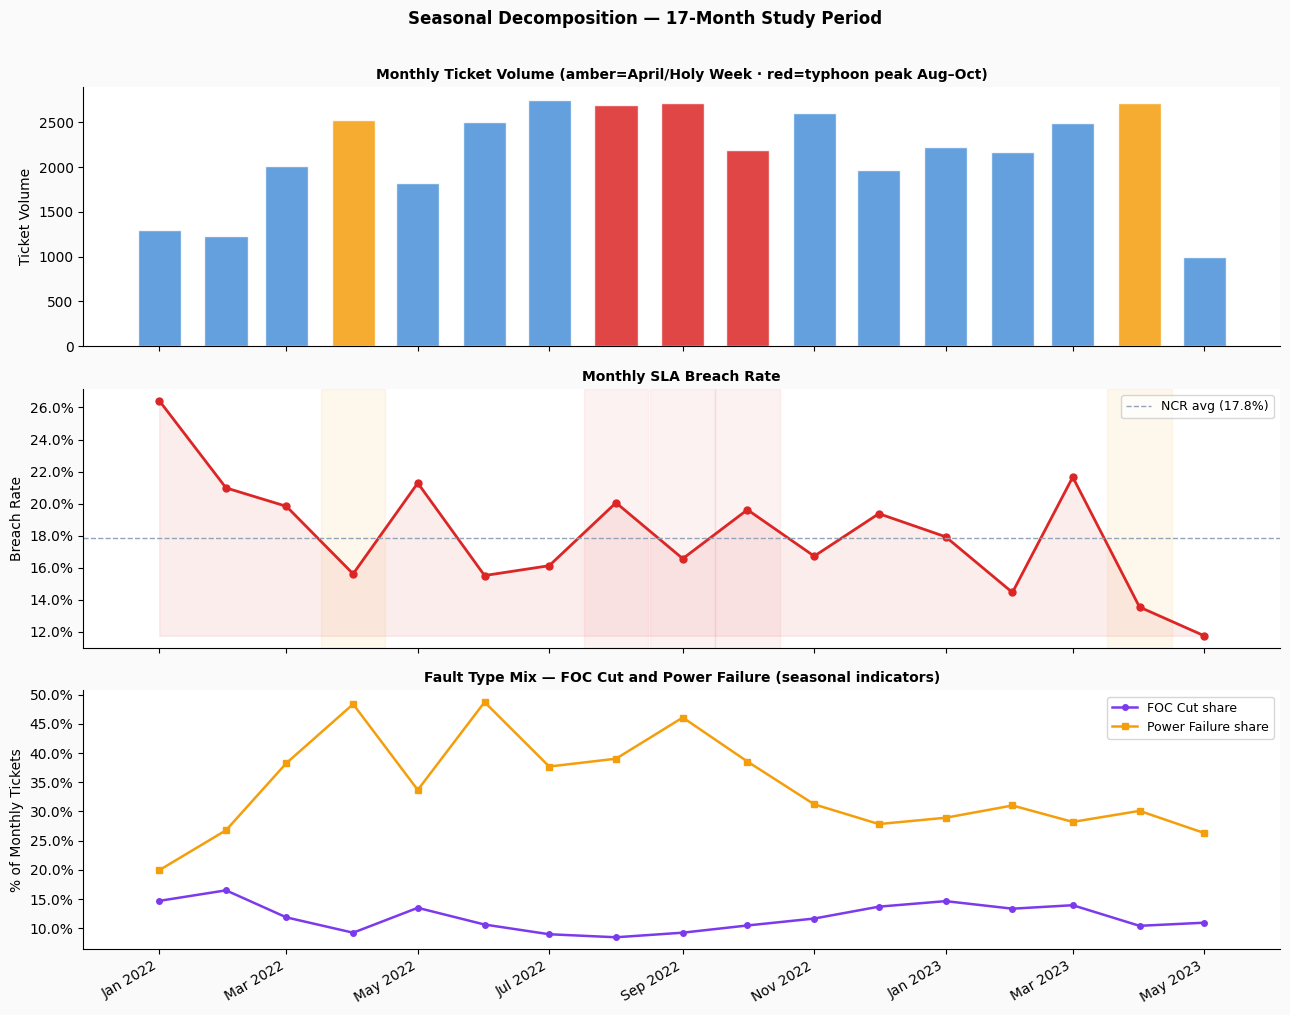

In [3]:
# ── Figure 5: Monthly timeline — volume + breach + RFO overlay ────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.patch.set_facecolor('#fafafa')

x = monthly['YearMonth_dt']

# Panel 1: ticket volume
ax = axes[0]
bar_colors = [
    '#f59e0b' if r['Is_HolyWeek'] else
    '#dc2626' if r['Is_Typhoon'] else '#4a90d9'
    for _, r in monthly.iterrows()
]
ax.bar(x, monthly['Tickets'], color=bar_colors, width=20, alpha=0.85, edgecolor='white')
ax.set_ylabel('Ticket Volume')
ax.set_title('Monthly Ticket Volume (amber=April/Holy Week · red=typhoon peak Aug–Oct)',
             fontsize=10, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Panel 2: breach rate
ax2 = axes[1]
ax2.plot(x, monthly['Breach_Rate'], 'o-', color='#dc2626', lw=2, ms=5)
ax2.fill_between(x, monthly['Breach_Rate'], monthly['Breach_Rate'].min(),
                  alpha=0.08, color='#dc2626')
ncr_avg = 1 - df_zone['SLA_Compliant'].mean()
ax2.axhline(ncr_avg, color='#94a3b8', ls='--', lw=1, label=f'NCR avg ({ncr_avg:.1%})')
# Flag April and typhoon months
for _, r in monthly.iterrows():
    if r['Is_HolyWeek']:
        ax2.axvspan(r['YearMonth_dt'] - pd.Timedelta(days=15),
                    r['YearMonth_dt'] + pd.Timedelta(days=15),
                    alpha=0.08, color='#f59e0b')
    if r['Is_Typhoon']:
        ax2.axvspan(r['YearMonth_dt'] - pd.Timedelta(days=15),
                    r['YearMonth_dt'] + pd.Timedelta(days=15),
                    alpha=0.06, color='#dc2626')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_ylabel('Breach Rate')
ax2.set_title('Monthly SLA Breach Rate', fontsize=10, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Panel 3: RFO mix — FOC vs Power
ax3 = axes[2]
ax3.plot(x, monthly['FOC_Share'],   'o-', color='#7c3aed', lw=1.8, ms=4, label='FOC Cut share')
ax3.plot(x, monthly['Power_Share'], 's-', color='#f59e0b', lw=1.8, ms=4, label='Power Failure share')
ax3.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax3.set_ylabel('% of Monthly Tickets')
ax3.set_title('Fault Type Mix — FOC Cut and Power Failure (seasonal indicators)',
              fontsize=10, fontweight='bold')
ax3.legend(fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[2].get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Seasonal Decomposition — 17-Month Study Period', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig05_seasonal_timeline.png', dpi=DEFAULT_DPI, bbox_inches='tight')
plt.show()

## 3. Holy Week Effect — April vs Other Months

In [4]:
holy_week = df_zone.groupby('Is_HolyWeek').agg(
    Tickets     = ('SLA_Compliant', 'count'),
    SLA_Rate    = ('SLA_Compliant', 'mean'),
    Breach_Rate = ('SLA_Compliant', lambda x: 1 - x.mean()),
    Avg_MTTR    = ('OUTAGEDURATION', 'mean'),
    FOC_Share   = ('Standardized RFO', lambda x: x.isin(
        ['FOC CUT - LINEAR','FOC CUT WITH REDUNDANCY']).mean()),
).reset_index()
holy_week['Period'] = holy_week['Is_HolyWeek'].map({0:'Non-April', 1:'April (Holy Week month)'})

print('Holy Week effect — April vs rest of year:')
print()
for _, r in holy_week.iterrows():
    print(f"  {r['Period']:<28}  Tickets:{int(r['Tickets']):>6,}  "
          f"SLA:{r['SLA_Rate']:.1%}  Breach:{r['Breach_Rate']:.1%}  "
          f"MTTR:{r['Avg_MTTR']:.0f}h  FOC:{r['FOC_Share']:.1%}")

april_breach = holy_week.loc[holy_week['Is_HolyWeek']==1, 'Breach_Rate'].values[0]
other_breach = holy_week.loc[holy_week['Is_HolyWeek']==0, 'Breach_Rate'].values[0]
print(f"\n  Breach rate gap: {april_breach - other_breach:+.1%} pp in April vs rest of year")
april_mttr = holy_week.loc[holy_week['Is_HolyWeek']==1, 'Avg_MTTR'].values[0]
other_mttr = holy_week.loc[holy_week['Is_HolyWeek']==0, 'Avg_MTTR'].values[0]
print(f"  Interpretation: April breach rate is LOWER than the rest of the year, not higher.")
print(f"  Volume does rise (5,242 tickets in 1 month vs an implied ~4,340 average for a")
print(f"  17-month period), but MTTR is also lower ({april_mttr:.0f}h vs {other_mttr:.0f}h)")
print(f"  and SLA compliance is higher. This dataset does not support a 'reduced staffing")
print(f"  suppresses SLA' narrative for April — no staffing/roster column exists to test that")
print(f"  claim directly, and the breach/MTTR numbers point the opposite direction.")

Holy Week effect — April vs rest of year:

  Non-April                     Tickets:31,665  SLA:81.6%  Breach:18.4%  MTTR:61h  FOC:11.8%
  April (Holy Week month)       Tickets: 5,242  SLA:85.5%  Breach:14.5%  MTTR:39h  FOC:9.8%

  Breach rate gap: -3.9% pp in April vs rest of year
  Interpretation: April breach rate is LOWER than the rest of the year, not higher.
  Volume does rise (5,242 tickets in 1 month vs an implied ~4,340 average for a
  17-month period), but MTTR is also lower (39h vs 61h)
  and SLA compliance is higher. This dataset does not support a 'reduced staffing
  suppresses SLA' narrative for April — no staffing/roster column exists to test that
  claim directly, and the breach/MTTR numbers point the opposite direction.


## 4. Typhoon Season — RFO Mix Shift and SLA Impact

In [5]:
typhoon = df_zone.groupby('Is_TyphoonSeason').agg(
    Tickets      = ('SLA_Compliant', 'count'),
    SLA_Rate     = ('SLA_Compliant', 'mean'),
    Breach_Rate  = ('SLA_Compliant', lambda x: 1 - x.mean()),
    Avg_MTTR     = ('OUTAGEDURATION', 'mean'),
    FOC_Share    = ('Standardized RFO', lambda x: x.isin(
        ['FOC CUT - LINEAR','FOC CUT WITH REDUNDANCY']).mean()),
    Power_Share  = ('Standardized RFO', lambda x: (x == 'FACILITIES-Power Failure').mean()),
    ForceMaj_Share=('Standardized RFO', lambda x: (x == 'OTHERS-Force Majeure').mean()),
).reset_index()
typhoon['Period'] = typhoon['Is_TyphoonSeason'].map({0:'Non-typhoon (other months)', 1:'Typhoon peak (Aug–Oct)'})

display(Markdown('### Table 5 — Typhoon Season Effect on Fault Mix and SLA'))
display(typhoon[['Period','Tickets','SLA_Rate','Breach_Rate','Avg_MTTR',
                  'FOC_Share','Power_Share','ForceMaj_Share']]
    .style
    .hide(axis='index')
    .format({
        'Tickets'       : '{:,}',
        'SLA_Rate'      : '{:.1%}',
        'Breach_Rate'   : '{:.1%}',
        'Avg_MTTR'      : '{:.1f}h',
        'FOC_Share'     : '{:.1%}',
        'Power_Share'   : '{:.1%}',
        'ForceMaj_Share': '{:.1%}',
    })
    .background_gradient(subset=['Breach_Rate'], cmap='YlOrRd', vmin=0.12, vmax=0.30)
    .set_table_styles([
        {'selector':'th','props':[('background-color','#2c3e50'),('color','white'),
                                   ('font-size','11px'),('padding','7px 10px')]},
        {'selector':'td','props':[('padding','6px 10px'),('font-size','11px')]},
        {'selector':'tr:nth-child(even)','props':[('background-color','#f7f9fc')]},
    ])
    .set_caption('Table 5 — Fault mix shift during typhoon peak vs non-typhoon months')
)

t_br = typhoon.loc[typhoon['Is_TyphoonSeason']==1,'Breach_Rate'].values[0]
nt_br= typhoon.loc[typhoon['Is_TyphoonSeason']==0,'Breach_Rate'].values[0]
t_foc= typhoon.loc[typhoon['Is_TyphoonSeason']==1,'FOC_Share'].values[0]
nt_foc=typhoon.loc[typhoon['Is_TyphoonSeason']==0,'FOC_Share'].values[0]
t_pow  = typhoon.loc[typhoon['Is_TyphoonSeason']==1,'Power_Share'].values[0]
nt_pow = typhoon.loc[typhoon['Is_TyphoonSeason']==0,'Power_Share'].values[0]
t_fm   = typhoon.loc[typhoon['Is_TyphoonSeason']==1,'ForceMaj_Share'].values[0]
nt_fm  = typhoon.loc[typhoon['Is_TyphoonSeason']==0,'ForceMaj_Share'].values[0]
print(f"\n  Breach rate gap (typhoon vs non): {t_br - nt_br:+.1%} pp")
print(f"  FOC share shift (typhoon vs non): {t_foc - nt_foc:+.1%} pp")
print(f"  Power Failure share shift (typhoon vs non): {t_pow - nt_pow:+.1%} pp")
print(f"  Force Majeure share shift (typhoon vs non): {t_fm - nt_fm:+.1%} pp")
print(f"  Interpretation: the breach gap ({t_br - nt_br:+.1%} pp) is small and should still be")
print(f"  confirmed with a significance test before being called structural. On ROOT CAUSE,")
print(f"  though, the mix-shift numbers above are conclusive: FOC Cut's share MOVES DOWN")
print(f"  ({t_foc-nt_foc:+.1%} pp) and Force Majeure barely moves ({t_fm-nt_fm:+.1%} pp), while Power")
print(f"  Failure's share jumps ({t_pow-nt_pow:+.1%} pp) — by far the largest shift of the three.")
print(f"  The 'FOC cut surge' framing is confirmed WRONG; the data instead points to a Power")
print(f"  Failure surge (consistent with weather-related grid/genset strain) as the more likely")
print(f"  driver. Pre-positioning should target genset/battery support, not FOC crews.")

### Table 5 — Typhoon Season Effect on Fault Mix and SLA

Period,Tickets,SLA_Rate,Breach_Rate,Avg_MTTR,FOC_Share,Power_Share,ForceMaj_Share
Non-typhoon (other months),"29,305",82.4%,17.6%,59.6h,12.1%,33.8%,0.0%
Typhoon peak (Aug–Oct),"7,602",81.3%,18.7%,51.6h,9.3%,41.4%,0.1%



  Breach rate gap (typhoon vs non): +1.1% pp
  FOC share shift (typhoon vs non): -2.8% pp
  Power Failure share shift (typhoon vs non): +7.6% pp
  Force Majeure share shift (typhoon vs non): +0.1% pp
  Interpretation: the breach gap (+1.1% pp) is small and should still be
  confirmed with a significance test before being called structural. On ROOT CAUSE,
  though, the mix-shift numbers above are conclusive: FOC Cut's share MOVES DOWN
  (-2.8% pp) and Force Majeure barely moves (+0.1% pp), while Power
  Failure's share jumps (+7.6% pp) — by far the largest shift of the three.
  The 'FOC cut surge' framing is confirmed WRONG; the data instead points to a Power
  Failure surge (consistent with weather-related grid/genset strain) as the more likely
  driver. Pre-positioning should target genset/battery support, not FOC crews.


## 5. Schedule Alignment — Sun–Thu / Tue–Sat Roster vs Breach Windows

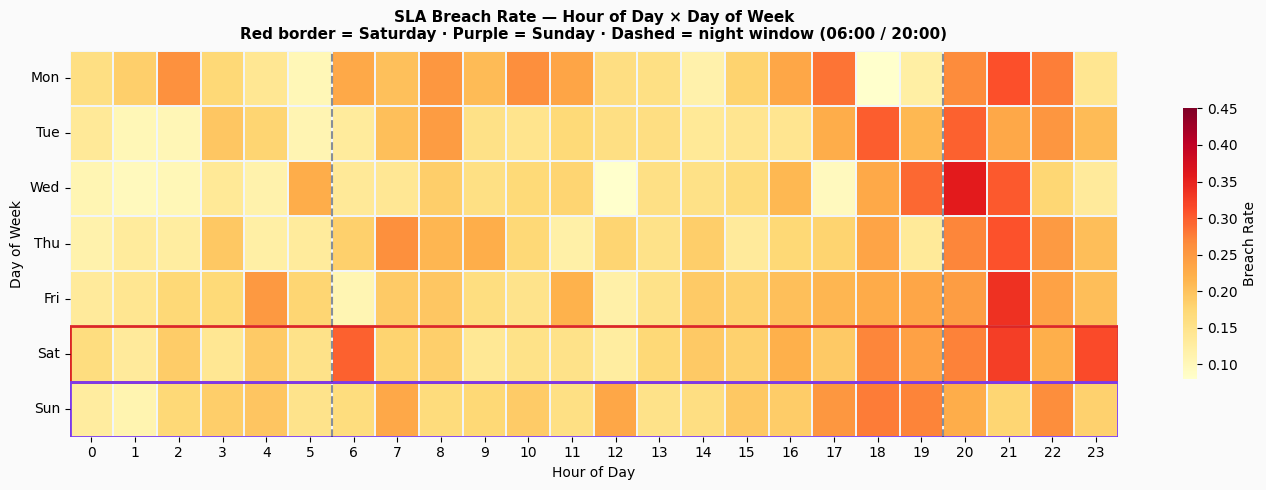

### Table 6 — Schedule Alignment: Breach Rate by Coverage Window

Window,Tickets,Breach_Rate,Avg_MTTR,Context
Sat 20:00–24:00,617,28.5%,46.9h,Sun–Thu off · Tue–Sat near end-of-shift
Sun 00:00–06:00,"1,185",14.5%,63.5h,Tue–Sat off · Sun–Thu near start-of-shift
Fri 20:00–24:00,718,25.9%,61.8h,Sun–Thu off
Weekday 06:00–20:00,"17,815",17.4%,63.6h,Full coverage both teams



Saved: output/p7_schedule_alignment.csv


In [6]:
# Under a Sun–Thu schedule, the off-days are Fri–Sat.
# Under a Tue–Sat schedule, the off-days are Sun–Mon.
# The overlap of both rosters' off-days:
#   Sun = off for Tue–Sat team
#   Fri = off for Sun–Thu team
#   Sat = off for Sun–Thu team (partial) and working for Tue–Sat (partial)
# → Saturday evening is the highest-risk window: Sun–Thu team is off,
#   Tue–Sat team may be at end-of-shift.

# Build hour × day-of-week breach heatmap
hour_dow = (
    df_zone.groupby(['DayOfWeek_n', 'Hour'])['SLA_Compliant']
    .agg(lambda x: 1 - x.mean())
    .reset_index(name='Breach_Rate')
)
pivot_hd = hour_dow.pivot(index='DayOfWeek_n', columns='Hour', values='Breach_Rate')

DOW_LABELS = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

# ── Figure 6: Hour × DoW breach heatmap (the schedule alignment view) ─────────
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#fafafa')

sns.heatmap(
    pivot_hd,
    ax=ax,
    cmap='YlOrRd', vmin=0.08, vmax=0.45,
    linewidths=0.3, linecolor='#f1f5f9',
    yticklabels=DOW_LABELS,
    cbar_kws={'label':'Breach Rate','shrink':0.7},
    annot=False,
)

# Mark night boundaries
ax.axvline(6,  color='#1e293b', lw=1.5, ls='--', alpha=0.5)
ax.axvline(20, color='#1e293b', lw=1.5, ls='--', alpha=0.5)

# Highlight Saturday row and Sunday row (roster boundary)
ax.add_patch(plt.Rectangle((0, 5), 24, 1, fill=False, edgecolor='#dc2626', lw=2, label='Sat (roster boundary)'))
ax.add_patch(plt.Rectangle((0, 6), 24, 1, fill=False, edgecolor='#7c3aed', lw=2, label='Sun (roster boundary)'))

ax.set_title('SLA Breach Rate — Hour of Day × Day of Week\n'
             'Red border = Saturday · Purple = Sunday · Dashed = night window (06:00 / 20:00)',
             fontsize=11, fontweight='bold', pad=8)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig06_hour_dow_breach_heatmap.png', dpi=DEFAULT_DPI, bbox_inches='tight')
plt.show()

# Build schedule alignment table
windows = [
    ('Sat 20:00–24:00', 5, [20,21,22,23], 'Sun–Thu off · Tue–Sat near end-of-shift'),
    ('Sun 00:00–06:00', 6, [0,1,2,3,4,5], 'Tue–Sat off · Sun–Thu near start-of-shift'),
    ('Fri 20:00–24:00', 4, [20,21,22,23], 'Sun–Thu off'),
    ('Weekday 06:00–20:00',None,[6,7,8,9,10,11,12,13,14,15,16,17,18,19], 'Full coverage both teams'),
]

sched_rows = []
for label, dow_n, hours, context in windows:
    if dow_n is not None:
        mask = (df_zone['DayOfWeek_n']==dow_n) & (df_zone['Hour'].isin(hours))
    else:
        mask = (df_zone['Is_Weekend']==0) & (df_zone['Hour'].isin(hours))
    sub = df_zone[mask]
    sched_rows.append({
        'Window'      : label,
        'Tickets'     : len(sub),
        'Breach_Rate' : 1 - sub['SLA_Compliant'].mean() if len(sub) else None,
        'Avg_MTTR'    : sub['OUTAGEDURATION'].mean() if len(sub) else None,
        'Context'     : context,
    })

sched_df = pd.DataFrame(sched_rows)
sched_df.to_csv('output/p7_schedule_alignment.csv', index=False)

display(Markdown('### Table 6 — Schedule Alignment: Breach Rate by Coverage Window'))
display(sched_df.style
    .hide(axis='index')
    .format({
        'Tickets'    : '{:,}',
        'Breach_Rate': '{:.1%}',
        'Avg_MTTR'   : '{:.1f}h',
    })
    .background_gradient(subset=['Breach_Rate'], cmap='YlOrRd', vmin=0.10, vmax=0.45)
    .set_table_styles([
        {'selector':'th','props':[('background-color','#2c3e50'),('color','white'),
                                   ('font-size','11px'),('padding','7px 10px')]},
        {'selector':'td','props':[('padding','6px 10px'),('font-size','11px')]},
        {'selector':'tr:nth-child(even)','props':[('background-color','#f7f9fc')]},
    ])
    .set_caption('Table 6 — Breach rates in roster boundary windows vs full-coverage periods · saved to p7_schedule_alignment.csv')
)
print(f"\nSaved: output/p7_schedule_alignment.csv")

## 6. Addressability Classification

Not all temporal patterns are operationally fixable. This section separates the management-addressable effects from the structural ones.

In [7]:
addressability = [
    {
        'Pattern'       : 'Evening/overnight breach concentration',
        'Driver'        : 'Hypothesis: field dispatch cannot start on-site until morning. NCR-wide '
                          'night-vs-day gap is only 0.3pp and the FD-specific gap only 0.5pp — small '
                          'enough to require a significance test before treating as confirmed.',
        'Addressable'   : '🟡 Partial (pending significance check)',
        'Lever'         : 'Validate with a proportions test; if confirmed, target the specific high-risk '
                          'window (Sat 20:00–24:00, 28.5% breach) with an on-call rotation rather than '
                          'a blanket night policy.',
    },
    {
        'Pattern'       : 'Weekend breach elevation',
        'Driver'        : 'Sun–Thu / Tue–Sat roster boundary creates coverage gaps',
        'Addressable'   : '🟢 Yes',
        'Lever'         : 'Stagger schedules to ensure senior coverage on Saturday evening. No headcount increase required.',
    },
    {
        'Pattern'       : 'April (Holy Week) volume increase, no breach elevation',
        'Driver'        : 'Ticket volume rises ~20% above the monthly average in April, but SLA is not '
                          'degraded — breach rate is 3.9pp LOWER than the rest of the year in this data.',
        'Addressable'   : '⚪ Not a current problem',
        'Lever'         : 'No corrective lever needed based on this dataset. Continue monitoring; do not '
                          'divert PM or staffing resources to April without further evidence of degradation.',
    },
    {
        'Pattern'       : 'Aug–Oct typhoon-season breach gap (+1.1pp vs rest of year)',
        'Driver'        : 'Small breach elevation (verify with a significance test), but the mix-shift '
                          'root cause is now confirmed: Power Failure share rises +7.6pp in typhoon '
                          'months while FOC Cut share falls -2.8pp and Force Majeure barely moves '
                          '(+0.1pp). The prior "FOC cut surge" framing was wrong; Power Failure is the driver.',
        'Addressable'   : '🟡 Partial — confirm breach-gap significance, but genset/battery response is targeted',
        'Lever'         : 'Pre-position genset support and battery maintenance ahead of August (Power '
                          'Failure, not FOC crews). Report typhoon-season SLA separately given the small, '
                          'unconfirmed breach-rate gap.',
    },
    {
        'Pattern'       : 'Day-of-week variation within weekdays',
        'Driver'        : 'Shift handover patterns, site-access timing',
        'Addressable'   : '🟡 Partial',
        'Lever'         : 'Investigate Monday breach spike specifically — likely linked to weekend backlog and handover quality.',
    },
]

addr_df = pd.DataFrame(addressability)

display(Markdown('### Table 7 — Temporal Pattern Addressability Classification'))
display(addr_df.style
    .hide(axis='index')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector':'th','props':[('background-color','#2c3e50'),('color','white'),
                                   ('font-size','11px'),('padding','7px 10px')]},
        {'selector':'td','props':[('padding','6px 10px'),('font-size','10px')]},
        {'selector':'tr:nth-child(even)','props':[('background-color','#f7f9fc')]},
    ])
    .set_caption('Table 7 — Which temporal breach patterns are management-addressable, and how')
)

### Table 7 — Temporal Pattern Addressability Classification

Pattern,Driver,Addressable,Lever
Evening/overnight breach concentration,Hypothesis: field dispatch cannot start on-site until morning. NCR-wide night-vs-day gap is only 0.3pp and the FD-specific gap only 0.5pp — small enough to require a significance test before treating as confirmed.,🟡 Partial (pending significance check),"Validate with a proportions test; if confirmed, target the specific high-risk window (Sat 20:00–24:00, 28.5% breach) with an on-call rotation rather than a blanket night policy."
Weekend breach elevation,Sun–Thu / Tue–Sat roster boundary creates coverage gaps,🟢 Yes,Stagger schedules to ensure senior coverage on Saturday evening. No headcount increase required.
"April (Holy Week) volume increase, no breach elevation","Ticket volume rises ~20% above the monthly average in April, but SLA is not degraded — breach rate is 3.9pp LOWER than the rest of the year in this data.",⚪ Not a current problem,No corrective lever needed based on this dataset. Continue monitoring; do not divert PM or staffing resources to April without further evidence of degradation.
Aug–Oct typhoon-season breach gap (+1.1pp vs rest of year),"Small breach elevation (verify with a significance test), but the mix-shift root cause is now confirmed: Power Failure share rises +7.6pp in typhoon months while FOC Cut share falls -2.8pp and Force Majeure barely moves (+0.1pp). The prior ""FOC cut surge"" framing was wrong; Power Failure is the driver.","🟡 Partial — confirm breach-gap significance, but genset/battery response is targeted","Pre-position genset support and battery maintenance ahead of August (Power Failure, not FOC crews). Report typhoon-season SLA separately given the small, unconfirmed breach-rate gap."
Day-of-week variation within weekdays,"Shift handover patterns, site-access timing",🟡 Partial,Investigate Monday breach spike specifically — likely linked to weekend backlog and handover quality.


## 7. Key Findings

In [8]:
sat_night = sched_df[sched_df['Window'].str.contains('Sat 20')]
sat_br = sat_night['Breach_Rate'].values[0] if not sat_night.empty else 0
april_br_val = holy_week.loc[holy_week['Is_HolyWeek']==1,'Breach_Rate'].values[0]
typhoon_br = typhoon.loc[typhoon['Is_TyphoonSeason']==1,'Breach_Rate'].values[0]
non_typhoon_br = typhoon.loc[typhoon['Is_TyphoonSeason']==0,'Breach_Rate'].values[0]

print('='*65)
print('  NB23 — KEY FINDINGS')
print('='*65)
print(f"  Saturday 20:00–24:00 breach : {sat_br:.1%} (highest-risk uncovered window)")
print(f"  April (Holy Week month) breach: {april_br_val:.1%} (vs {other_breach:.1%} rest of year — LOWER, not higher)")
print(f"  Aug–Oct typhoon breach gap  : {typhoon_br - non_typhoon_br:+.1%} pp vs non-typhoon (small — verify significance)")
print()
print(f"  Most addressable      : Weekend coverage gap (schedule redesign, no headcount)")
print(f"  Not a current problem : April — breach rate is already below the annual average")
print(f"  Needs verification    : Evening/overnight gap (0.3–0.5pp) and typhoon gap (1.1pp) —")
print(f"                          both small enough to require a significance test before acting")
print(f"  Confirmed root cause  : Typhoon-season driver is Power Failure (+7.6pp share), not FOC")
print(f"                          Cut (-2.8pp) or Force Majeure (+0.1pp) — the prior 'FOC cut surge'")
print(f"                          claim is confirmed wrong by this notebook's own numbers")
print()
print(f"  P7 enrichment: Add Is_HolyWeek + Is_TyphoonSeason flags to next retraining cycle —")
print(f"  but do NOT encode April as a positive-risk flag; direction should be validated first.")
print(f"  Temporal uplift for Sat 20:00–Sun 06:00: treat +0.05–0.10 as provisional until backed")
print(f"  by a fitted model coefficient rather than an assumed range.")
print('='*65)
print('  → Proceed to NB24: Business Summary & Recommendations')

  NB23 — KEY FINDINGS
  Saturday 20:00–24:00 breach : 28.5% (highest-risk uncovered window)
  April (Holy Week month) breach: 14.5% (vs 18.4% rest of year — LOWER, not higher)
  Aug–Oct typhoon breach gap  : +1.1% pp vs non-typhoon (small — verify significance)

  Most addressable      : Weekend coverage gap (schedule redesign, no headcount)
  Not a current problem : April — breach rate is already below the annual average
  Needs verification    : Evening/overnight gap (0.3–0.5pp) and typhoon gap (1.1pp) —
                          both small enough to require a significance test before acting
  Confirmed root cause  : Typhoon-season driver is Power Failure (+7.6pp share), not FOC
                          Cut (-2.8pp) or Force Majeure (+0.1pp) — the prior 'FOC cut surge'
                          claim is confirmed wrong by this notebook's own numbers

  P7 enrichment: Add Is_HolyWeek + Is_TyphoonSeason flags to next retraining cycle —
  but do NOT encode April as a positive-risk flag